In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os

# Vérification du GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)


Device utilisé : cuda


In [2]:
# Dossier racine de ton dataset
root_dir = "car_dataset/train"  # dossier créé par icrawler

# Transformations pour l'entrainement (avec augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Transformations pour la validation / test
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Dataset complet
full_dataset = datasets.ImageFolder(root=root_dir, transform=train_transform)
num_classes = len(full_dataset.classes)
print("Classes :", full_dataset.classes)

# Split train / val
val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

# Remplacer transform pour val_dataset
val_dataset.dataset.transform = val_transform

# DataLoaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


Classes : ['AM General Hummer SUV 2000', 'Acura Integra Type R 2001', 'Acura RL Sedan 2012', 'Acura TL Sedan 2012', 'Acura TL Type-S 2008', 'Acura TSX Sedan 2012', 'Acura ZDX Hatchback 2012', 'Aston Martin V8 Vantage Convertible 2012', 'Aston Martin V8 Vantage Coupe 2012', 'Aston Martin Virage Convertible 2012', 'Aston Martin Virage Coupe 2012', 'Audi 100 Sedan 1994', 'Audi 100 Wagon 1994', 'Audi A5 Coupe 2012', 'Audi R8 Coupe 2012', 'Audi RS 4 Convertible 2008', 'Audi S4 Sedan 2007', 'Audi S4 Sedan 2012', 'Audi S5 Convertible 2012', 'Audi S5 Coupe 2012', 'Audi S6 Sedan 2011', 'Audi TT Hatchback 2011', 'Audi TT RS Coupe 2012', 'Audi TTS Coupe 2012', 'Audi V8 Sedan 1994', 'BMW 1 Series Convertible 2012', 'BMW 1 Series Coupe 2012', 'BMW 3 Series Sedan 2012', 'BMW 3 Series Wagon 2012', 'BMW 6 Series Convertible 2007', 'BMW ActiveHybrid 5 Sedan 2012', 'BMW M3 Coupe 2012', 'BMW M5 Sedan 2010', 'BMW M6 Convertible 2010', 'BMW X3 SUV 2012', 'BMW X5 SUV 2007', 'BMW X6 SUV 2012', 'BMW Z4 Conver

In [3]:
# Utilisation d'un modèle pré-entraîné ResNet18
model = models.resnet18(pretrained=True)

# Remplacer la dernière couche pour notre nombre de classes
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# Criterion et optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [4]:
num_epochs = 30  # tu peux augmenter selon besoin

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / train_size
    epoch_acc = running_corrects.double() / train_size
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}")


Epoch 1/30 - Loss: 4.5659, Acc: 0.1177
Epoch 2/30 - Loss: 2.7441, Acc: 0.5330
Epoch 3/30 - Loss: 1.4240, Acc: 0.8525
Epoch 4/30 - Loss: 0.5658, Acc: 0.9765
Epoch 5/30 - Loss: 0.1986, Acc: 0.9952
Epoch 6/30 - Loss: 0.0904, Acc: 0.9974
Epoch 7/30 - Loss: 0.0530, Acc: 0.9983
Epoch 8/30 - Loss: 0.0365, Acc: 0.9983
Epoch 9/30 - Loss: 0.0294, Acc: 0.9982
Epoch 10/30 - Loss: 0.0251, Acc: 0.9972
Epoch 11/30 - Loss: 0.0223, Acc: 0.9980
Epoch 12/30 - Loss: 0.0254, Acc: 0.9971
Epoch 13/30 - Loss: 0.0331, Acc: 0.9969
Epoch 14/30 - Loss: 0.1125, Acc: 0.9885
Epoch 15/30 - Loss: 0.0373, Acc: 0.9960
Epoch 16/30 - Loss: 0.0200, Acc: 0.9971
Epoch 17/30 - Loss: 0.0104, Acc: 0.9979
Epoch 18/30 - Loss: 0.0113, Acc: 0.9972
Epoch 19/30 - Loss: 0.0070, Acc: 0.9985
Epoch 20/30 - Loss: 0.0065, Acc: 0.9982
Epoch 21/30 - Loss: 0.0065, Acc: 0.9980
Epoch 22/30 - Loss: 0.0055, Acc: 0.9983
Epoch 23/30 - Loss: 0.1976, Acc: 0.9619
Epoch 24/30 - Loss: 0.0218, Acc: 0.9972
Epoch 25/30 - Loss: 0.0085, Acc: 0.9982
Epoch 26/

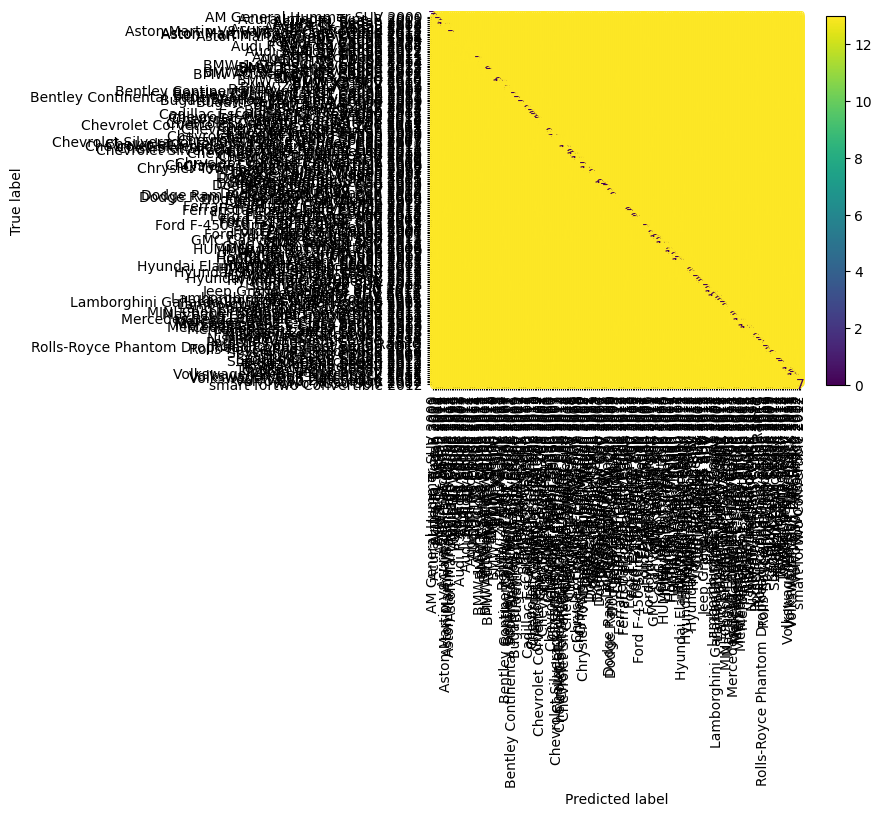

In [5]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=full_dataset.classes)
disp.plot(xticks_rotation=90)
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


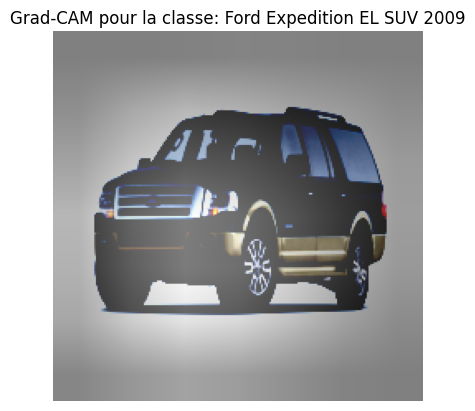

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import functional as F

# Sélection d'une image de validation
example_img, _ = val_dataset[0]
input_tensor = example_img.unsqueeze(0).to(device)

# Grad-CAM setup
gradients = []
activations = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# On hook la dernière couche conv (layer4[-1].conv2 pour ResNet18)
target_layer = model.layer4[-1].conv2
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

# Forward pass
model.eval()
output = model(input_tensor)
pred_class = output.argmax(dim=1)

# Backward pass
model.zero_grad()
output[:, pred_class].backward()

# Récupération des activations et gradients
grad = gradients[0].cpu().data.numpy()[0]
activation = activations[0].cpu().data.numpy()[0]

# Pondération des cartes d'activation par les gradients moyens
weights = np.mean(grad, axis=(1, 2))
cam = np.zeros(activation.shape[1:], dtype=np.float32)

for i, w in enumerate(weights):
    cam += w * activation[i]

# Normalisation
cam = np.maximum(cam, 0)
cam = cam / cam.max()

# Conversion en image
cam = np.uint8(cam * 255)
cam = np.stack([cam]*3, axis=2)
cam = F.resize(torch.tensor(cam).permute(2,0,1), [224,224])

# Affichage
plt.imshow(example_img.permute(1,2,0).cpu())  # image originale
plt.imshow(cam.permute(1,2,0), cmap='jet', alpha=0.5)  # superposé
plt.title(f"Grad-CAM pour la classe: {full_dataset.classes[pred_class]}")
plt.axis("off")
plt.show()
